# Cross-Dataset Evaluation

The model from `pneumonia_classification.ipynb` was trained and evaluated on the Kaggle chest X-ray dataset and achieved ~92% accuracy. That's on data from the **same distribution it was trained on**.

This notebook runs the **same model, zero retraining**, on a completely different dataset: chest X-rays from Epic Hospital, Chittagong, Bangladesh. Same task (normal vs pneumonia), different scanner, different patient population, different image characteristics.

The goal is to see if the model actually learned clinical pathology or just got good at recognizing patterns specific to one dataset.

In [8]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import shap
import cv2
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    accuracy_score, classification_report
)

# --- Config ---
ORIGINAL_TEST_DIR = "chest_xray/test"
NEW_DATASET_DIR   = "Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Testing"
MODEL_PATH        = "results/best_model.pth"
IMG_SIZE = 224
BATCH_SIZE = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

if torch.backends.mps.is_available(): DEVICE = torch.device("mps")
elif torch.cuda.is_available():       DEVICE = torch.device("cuda")
else:                                  DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

Device: mps


## 1. Load the Model

Exact same architecture as before — ResNet18 with a dropout + linear head. Loading the saved weights, no retraining.

In [9]:
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 1)
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print("Model loaded.")

Model loaded.


## 2. Load Both Datasets

Same preprocessing pipeline applied to both — resize, grayscale→3ch, normalize with ImageNet stats. The only difference is the source of images.

In [10]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

raw_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

original_dataset = datasets.ImageFolder(ORIGINAL_TEST_DIR, transform=eval_transform)
new_dataset = datasets.ImageFolder(NEW_DATASET_DIR, transform=eval_transform)
new_dataset_raw = datasets.ImageFolder(NEW_DATASET_DIR, transform=raw_transform)

original_loader = DataLoader(original_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
new_loader = DataLoader(new_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Original test set  — classes: {original_dataset.classes}, n={len(original_dataset)}")
print(f"New (Chittagong)   — classes: {new_dataset.classes},      n={len(new_dataset)}")

Original test set  — classes: ['NORMAL', 'PNEUMONIA'], n=624
New (Chittagong)   — classes: ['normal', 'pneumonia'],      n=513


## 3. Run Inference on Both

In [11]:
def run_inference(loader):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            out = model(images).squeeze()
            # handle single-image batches
            if out.dim() == 0:
                out = out.unsqueeze(0)
            probs = torch.sigmoid(out).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)

orig_probs, orig_labels = run_inference(original_loader)
new_probs, new_labels = run_inference(new_loader)

print(f"Processed {len(orig_labels)} original images, {len(new_labels)} new images.")

Processed 624 original images, 513 new images.


## 4. Side-by-Side Metrics

In [20]:
def compute_metrics(probs, labels, name):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    preds = (probs >= best_thresh).astype(int)
    acc = accuracy_score(labels, preds)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  AUC:      {roc_auc:.4f}")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print()
    print(classification_report(labels, preds, labels=[0, 1], target_names=['Normal', 'Pneumonia']))
    return fpr, tpr, roc_auc, best_thresh

orig_fpr, orig_tpr, orig_auc, orig_thresh = compute_metrics(orig_probs, orig_labels, "Original Kaggle Test Set")
new_fpr, new_tpr, new_auc, new_thresh = compute_metrics(new_probs, new_labels, "New Dataset (Chittagong)")


  Original Kaggle Test Set
  AUC:      0.9694
  Accuracy: 0.9279 (92.8%)

              precision    recall  f1-score   support

      Normal       0.91      0.90      0.90       234
   Pneumonia       0.94      0.94      0.94       390

    accuracy                           0.93       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.93      0.93      0.93       624


  New Dataset (Chittagong)
  AUC:      0.7189
  Accuracy: 0.7797 (78.0%)

              precision    recall  f1-score   support

      Normal       0.72      0.92      0.81       257
   Pneumonia       0.89      0.64      0.74       256

    accuracy                           0.78       513
   macro avg       0.80      0.78      0.78       513
weighted avg       0.80      0.78      0.78       513



## 5. ROC Curves — Overlaid

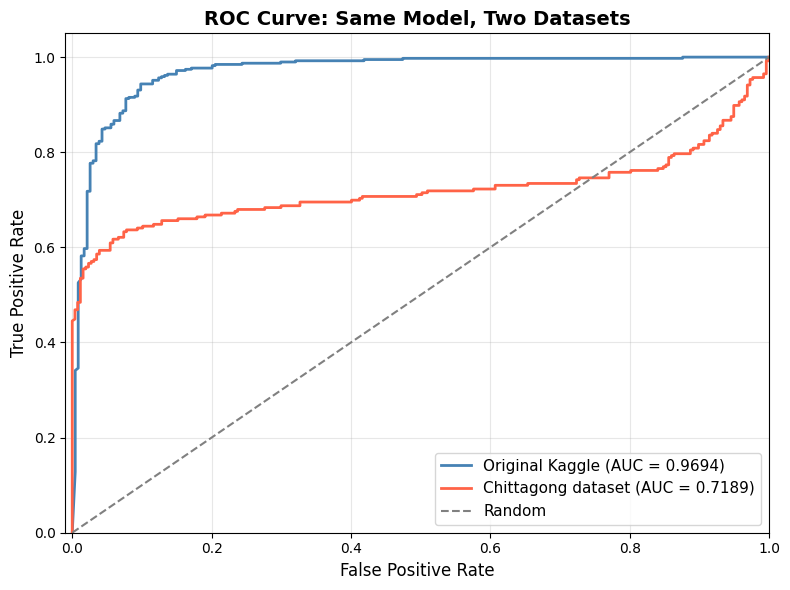

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(orig_fpr, orig_tpr, color='steelblue', lw=2,
         label=f'Original Kaggle (AUC = {orig_auc:.4f})')
plt.plot(new_fpr, new_tpr, color='tomato', lw=2,
         label=f'Chittagong dataset (AUC = {new_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: Same Model, Two Datasets', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Confusion Matrices — Side by Side

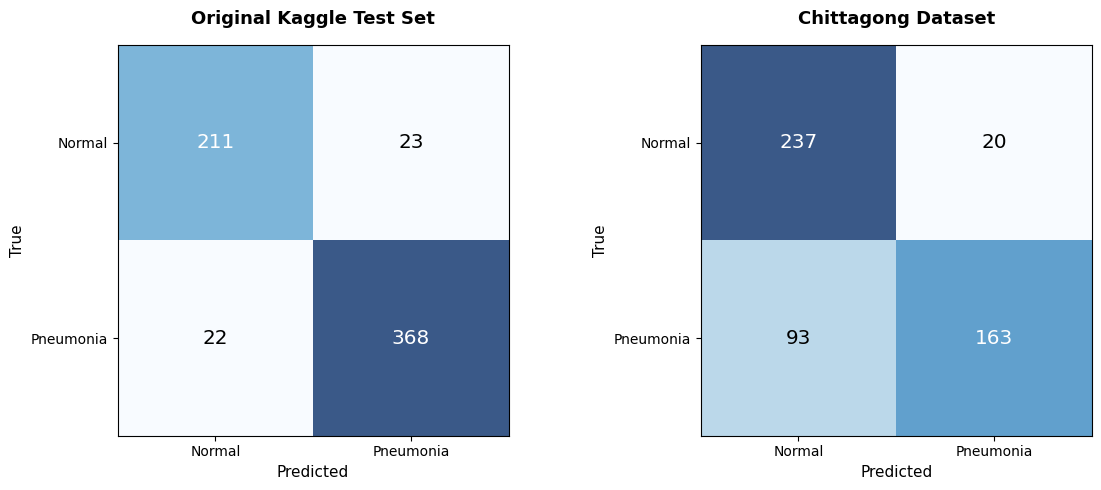

In [14]:
def plot_cm(ax, labels, probs, thresh, title):
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(labels, preds)
    ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), va='center', ha='center', size='x-large',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Pneumonia'])
    ax.set_yticklabels(['Normal', 'Pneumonia'])
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(ax1, orig_labels, orig_probs, orig_thresh, 'Original Kaggle Test Set')
plot_cm(ax2, new_labels, new_probs, new_thresh, 'Chittagong Dataset')
plt.tight_layout()
plt.show()